# Multiband k.p, step 1: validate the bulk Luttinger-Kohn Hamiltonian

Before discretizing k -> operators on a 3D grid (which needs careful, error-prone treatment
of cross-derivative terms like $k_x k_y$), validate the 6-band Luttinger-Kohn Hamiltonian
itself against known bulk physics, with $k$ still just a number rather than an operator --
the same "test against a known case before trusting it" discipline that caught the unit and
boundary-condition bugs in the single-band solver.

Three checks:
1. **Hermiticity** at generic $\mathbf{k}$ (guaranteed by construction here, but worth
   confirming, and won't be automatic once this gets discretized on a grid)
2. **$\mathbf{k}=0$ eigenvalues** match the split-off energy exactly
3. **Effective masses** along the Hamiltonian's special axis ($k_z$) match
   $1/m_\mathrm{hh}=\gamma_1-2\gamma_2$, $1/m_\mathrm{lh}=\gamma_1+2\gamma_2$ -- the same formula
   `aestimo.py`'s own `Strain_and_Masses` function uses.

Then: a bulk dispersion plot showing valence-band warping -- the anisotropic mixing between
heavy and light hole character away from the special axis, which is exactly the kind of
physics a single band cannot capture and is the whole motivation for doing this.

In [1]:
import sys, os
sys.path.insert(0, os.getcwd())

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import qdsolver_core as qd
from kp_luttinger import luttinger_kohn_bulk, BAND_LABELS

## Check 1: Hermiticity at generic k

In [2]:
rng = np.random.default_rng(0)
for material in ['GaAs', 'InAs', 'InSb']:
    mat = qd.MATERIALS[material]
    args = (mat['gamma1'], mat['gamma2'], mat['gamma3'], mat['delta_so'])
    max_err = 0.0
    for _ in range(200):
        kx, ky, kz = rng.uniform(-2, 2, 3)
        H = luttinger_kohn_bulk(kx, ky, kz, *args)
        max_err = max(max_err, np.max(np.abs(H - H.conj().T)))
    print(f"{material}: max |H - H^dagger| over 200 random k = {max_err:.2e}")

GaAs: max |H - H^dagger| over 200 random k = 0.00e+00
InAs: max |H - H^dagger| over 200 random k = 0.00e+00
InSb: max |H - H^dagger| over 200 random k = 0.00e+00


## Check 2: $k=0$ eigenvalues

In [3]:
for material in ['GaAs', 'InAs', 'InSb']:
    mat = qd.MATERIALS[material]
    args = (mat['gamma1'], mat['gamma2'], mat['gamma3'], mat['delta_so'])
    evals0 = np.sort(np.linalg.eigvalsh(luttinger_kohn_bulk(0, 0, 0, *args)))
    print(f"{material}: E(k=0) = {np.round(evals0*1e3, 4)} meV "
          f"(expect two states at -delta_so={-mat['delta_so']*1e3:.1f} meV, four at 0)")

GaAs: E(k=0) = [-280. -280.    0.    0.    0.    0.] meV (expect two states at -delta_so=-280.0 meV, four at 0)
InAs: E(k=0) = [-380. -380.    0.    0.    0.    0.] meV (expect two states at -delta_so=-380.0 meV, four at 0)
InSb: E(k=0) = [-810. -810.    0.    0.    0.    0.] meV (expect two states at -delta_so=-810.0 meV, four at 0)


## Check 3: effective masses along $k_z$ (this Hamiltonian's special axis)

$R$ and $S$ (the terms responsible for HH-LH-SO mixing) both vanish identically when
$k_x=k_y=0$, so along $k_z$ the 6x6 Hamiltonian block-diagonalizes into two pure heavy-hole
eigenstates plus two identical light-hole/split-off 2x2 blocks (coupled through the $Q$ term,
which doesn't vanish along this axis). That means:
- the **heavy-hole** mass should match $1/m_\mathrm{hh}=\gamma_1-2\gamma_2$ *exactly* -- it
  never couples to anything along this axis
- the **light-hole** mass should match $1/m_\mathrm{lh}=\gamma_1+2\gamma_2$ only *approximately*
  -- finite coupling to the split-off band (visible below as an explicit 2x2 block) pulls it
  away slightly, more so as $k$ grows or $\Delta_\mathrm{so}$ shrinks. This is a real 6-band
  effect the simpler 4-band (no split-off) formula aestimo uses doesn't capture, not a bug --
  it should shrink as $k\to0$.

In [4]:
for material in ['GaAs', 'InAs']:
    mat = qd.MATERIALS[material]
    g1, g2, g3, dso = mat['gamma1'], mat['gamma2'], mat['gamma3'], mat['delta_so']
    inv_m_hh_expected, inv_m_lh_expected = g1 - 2 * g2, g1 + 2 * g2  # 1/m, in units of 1/m0

    print(f"=== {material} ===")
    for k in [0.01, 0.05, 0.2]:
        H = luttinger_kohn_bulk(0, 0, k, g1, g2, g3, dso)
        evals = np.sort(np.linalg.eigvalsh(H))
        # ascending order for gamma2>0: [SO,SO, HH,HH, LH,LH] (HH has the *smaller*
        # coefficient gamma1-2*gamma2, so it's the lower of the two positive-energy pairs)
        E_hh = evals[2]
        E_lh = evals[4]
        inv_m_hh_numeric = E_hh / (qd.HBAR2_OVER_2M0 * k**2)
        inv_m_lh_numeric = E_lh / (qd.HBAR2_OVER_2M0 * k**2)
        print(f"  k={k:.2f}/nm: 1/m_hh numeric={inv_m_hh_numeric:.4f} vs expected={inv_m_hh_expected:.4f}  "
              f"(diff {abs(inv_m_hh_numeric-inv_m_hh_expected):.2e}); "
              f"1/m_lh numeric={inv_m_lh_numeric:.4f} vs expected={inv_m_lh_expected:.4f} "
              f"(diff {abs(inv_m_lh_numeric-inv_m_lh_expected):.2e})")

=== GaAs ===
  k=0.01/nm: 1/m_hh numeric=3.0000 vs expected=3.0000  (diff 6.83e-12); 1/m_lh numeric=10.6004 vs expected=10.6000 (diff 3.93e-04)
  k=0.05/nm: 1/m_hh numeric=3.0000 vs expected=3.0000  (diff 4.44e-16); 1/m_lh numeric=10.6098 vs expected=10.6000 (diff 9.81e-03)
  k=0.20/nm: 1/m_hh numeric=3.0000 vs expected=3.0000  (diff 1.55e-14); 1/m_lh numeric=10.7539 vs expected=10.6000 (diff 1.54e-01)
=== InAs ===
  k=0.01/nm: 1/m_hh numeric=3.8000 vs expected=3.8000  (diff 1.78e-15); 1/m_lh numeric=37.0055 vs expected=37.0000 (diff 5.52e-03)
  k=0.05/nm: 1/m_hh numeric=3.8000 vs expected=3.8000  (diff 4.86e-13); 1/m_lh numeric=37.1376 vs expected=37.0000 (diff 1.38e-01)
  k=0.20/nm: 1/m_hh numeric=3.8000 vs expected=3.8000  (diff 1.20e-14); 1/m_lh numeric=39.0564 vs expected=37.0000 (diff 2.06e+00)


## Bulk dispersion: heavy hole / light hole / split-off bands, and warping

Along $k_z$ (this Hamiltonian's special axis) the bands are smooth parabolas with no HH-LH
mixing. Along a generic direction like $[110]$, $R$ and $S$ no longer vanish and the bands mix
and "warp" (become visibly non-parabolic/anisotropic) -- this anisotropic mixing is exactly
the physics a single parabolic band cannot represent.

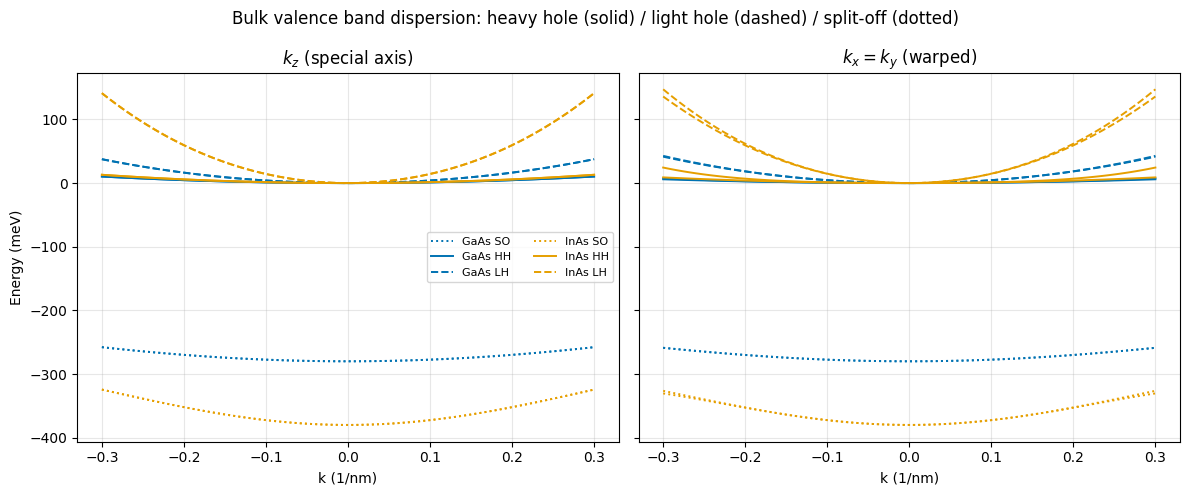

In [5]:
def dispersion_along(direction, k_values, gamma1, gamma2, gamma3, delta_so):
    direction = np.array(direction) / np.linalg.norm(direction)
    energies = np.zeros((len(k_values), 6))
    for i, k in enumerate(k_values):
        kx, ky, kz = k * direction
        H = luttinger_kohn_bulk(kx, ky, kz, gamma1, gamma2, gamma3, delta_so)
        energies[i] = np.sort(np.linalg.eigvalsh(H))
    return energies

# With eigenvalues sorted ascending and gamma2>0 (true for GaAs/InAs/InSb), band identity by
# position is [SO,SO, HH,HH, LH,LH] near zone center -- see Check 3 above for why (HH has the
# smaller |gamma1-2*gamma2| coefficient of the two positive-energy pairs, SO sits well below
# both). This ordering can in principle break down via band crossings far from zone center,
# but holds throughout the modest k range plotted here.
BAND_TYPE_BY_SORTED_INDEX = ["SO", "SO", "HH", "HH", "LH", "LH"]
LINESTYLE_BY_BAND_TYPE = {"SO": ":", "HH": "-", "LH": "--"}

k_values = np.linspace(-0.3, 0.3, 121)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for material, color in zip(['GaAs', 'InAs'], ["#0072B2", "#E69F00"]):
    mat = qd.MATERIALS[material]
    args = (mat['gamma1'], mat['gamma2'], mat['gamma3'], mat['delta_so'])
    for ax, direction, title in zip(axes, [(0, 0, 1), (1, 1, 0)], ["$k_z$ (special axis)", "$k_x=k_y$ (warped)"]):
        E = dispersion_along(direction, k_values, *args) * 1e3
        seen_labels = set()
        for b in range(6):
            band_type = BAND_TYPE_BY_SORTED_INDEX[b]
            label_key = (material, band_type)
            label = f"{material} {band_type}" if label_key not in seen_labels else None
            seen_labels.add(label_key)
            ax.plot(k_values, E[:, b], color=color, lw=1.4, ls=LINESTYLE_BY_BAND_TYPE[band_type],
                    label=label)
        ax.set_title(title)
        ax.set_xlabel("k (1/nm)")
        ax.grid(True, alpha=0.3)
axes[0].set_ylabel("Energy (meV)")
axes[0].legend(fontsize=8, ncol=2)
fig.suptitle("Bulk valence band dispersion: heavy hole (solid) / light hole (dashed) / split-off (dotted)")
fig.tight_layout()